In [9]:
# ==============================================================================
# Cell 1: Environment Setup and Data Loading (WDBC Dataset)
# Objective: Load robust preprocessed data avoiding any data leakage
# ==============================================================================

# Install required packages if not available
import subprocess
import sys

def install_if_missing(package):
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

install_if_missing('xgboost')
install_if_missing('shap')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Advanced ML Models
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Model Selection & Evaluation Metrics
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, precision_recall_curve, 
                             auc, confusion_matrix)

# Set publication-quality plot styles (First Class Standard)
sns.set_theme(style='whitegrid', context='paper')
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 14, 'axes.titleweight': 'bold'})

# Use relative path for portability
DATA_DIR = '../Dataset'

try:
    # 1. Load Training Data (SMOTE version to ensure balanced learning)
    X_train = pd.read_csv(f'{DATA_DIR}/X_train_smote.csv')
    y_train = pd.read_csv(f'{DATA_DIR}/y_train_smote.csv').values.ravel()
    
    # 2. Load Testing Data (Strictly untouched original distribution)
    X_test = pd.read_csv(f'{DATA_DIR}/X_test_scaled.csv')
    y_test = pd.read_csv(f'{DATA_DIR}/y_test.csv').values.ravel()
    
    print("SUCCESS: WDBC Data loaded perfectly!")
    print(f"-> Training features shape: {X_train.shape} (Balanced via SMOTE)")
    print(f"-> Testing features shape:  {X_test.shape}  (Original Distribution)")
    print(f"-> Sample feature names: {list(X_train.columns[:3])}...")
    
except FileNotFoundError as e:
    print(f"ERROR: File not found. Details: {e}")
    print("\nPlease run 01_EDA_Preprocessing.ipynb first to generate the preprocessed CSV files in the Dataset folder!")
except Exception as e:
    print(f"ERROR: An unexpected error occurred: {e}")

Installing xgboost...
Installing shap...
SUCCESS: WDBC Data loaded perfectly!
-> Training features shape: (570, 30) (Balanced via SMOTE)
-> Testing features shape:  (114, 30)  (Original Distribution)
-> Sample feature names: ['radius_mean', 'texture_mean', 'perimeter_mean']...


In [10]:
# ==============================================================================
# Cell 2: Constrained Random Forest (Bagging Ensemble)
# Objective: Train a robust model with hyperparameter tuning to prevent overfitting
# ==============================================================================

print(" Tuning and Training Constrained Random Forest...")
start_time = time.time()

# 1. Define the parameter grid (Ablation/Constraint Strategy)
rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7],           # CONSTRAINT: Prevent infinitely deep trees
    'min_samples_leaf': [2, 5, 10],   # CONSTRAINT: Prevent memorizing SMOTE noise
    'max_features': ['sqrt', 'log2']
}

# 2. Initialize base model (class_weight balanced for extra safety)
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

# 3. RandomizedSearchCV (Optimizing for Recall)
rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

# 4. Fit and Extract best model
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

# 5. Predict on Test Set
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# 6. Calculate all 6 required metrics
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

rf_precisions, rf_recalls, _ = precision_recall_curve(y_test, y_prob_rf)
rf_pr_auc = auc(rf_recalls, rf_precisions)

print(f" RF Training Complete in {time.time() - start_time:.1f} seconds!")
print(f" Best RF Parameters: {rf_search.best_params_}")
print("\n=============================================")
print(" CONSTRAINED RANDOM FOREST TEST PERFORMANCE")
print("=============================================")
print(f"Accuracy:             {rf_acc:.4f}")
print(f"Precision:            {rf_precision:.4f}")
print(f"Recall (Sensitivity): {rf_recall:.4f}")
print(f"F1-Score:             {rf_f1:.4f}")
print(f"ROC-AUC:              {rf_auc:.4f}")
print(f"PR-AUC:               {rf_pr_auc:.4f}")
print("=============================================")

 Tuning and Training Constrained Random Forest...
 RF Training Complete in 114.8 seconds!
 Best RF Parameters: {'n_estimators': 300, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 7}

 CONSTRAINED RANDOM FOREST TEST PERFORMANCE
Accuracy:             0.9737
Precision:            1.0000
Recall (Sensitivity): 0.9286
F1-Score:             0.9630
ROC-AUC:              0.9967
PR-AUC:               0.9946


In [11]:
# ==============================================================================
# Cell 3: XGBoost Classifier (Boosting Ensemble Comparison)
# Objective: Evaluate if sequential error-correction outperforms parallel voting
# ==============================================================================

print(" Tuning and Training XGBoost...")
start_time_xgb = time.time()

# 1. Define the XGBoost parameter grid
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 2. Initialize base XGBoost model
xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# 3. RandomizedSearchCV for XGBoost
xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

# 4. Fit and Extract best model
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

# 5. Predict on Test Set
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# 6. Calculate all 6 required metrics
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

xgb_precisions, xgb_recalls, _ = precision_recall_curve(y_test, y_prob_xgb)
xgb_pr_auc = auc(xgb_recalls, xgb_precisions)

print(f" XGB Training Complete in {time.time() - start_time_xgb:.1f} seconds!")
print(f" Best XGB Parameters: {xgb_search.best_params_}")
print("\n=============================================")
print(" XGBOOST TEST PERFORMANCE")
print("=============================================")
print(f"Accuracy:             {xgb_acc:.4f}")
print(f"Precision:            {xgb_precision:.4f}")
print(f"Recall (Sensitivity): {xgb_recall:.4f}")
print(f"F1-Score:             {xgb_f1:.4f}")
print(f"ROC-AUC:              {xgb_auc:.4f}")
print(f"PR-AUC:               {xgb_pr_auc:.4f}")
print("=============================================")

 Tuning and Training XGBoost...
 XGB Training Complete in 44.0 seconds!
 Best XGB Parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

 XGBOOST TEST PERFORMANCE
Accuracy:             0.9649
Precision:            1.0000
Recall (Sensitivity): 0.9048
F1-Score:             0.9500
ROC-AUC:              0.9940
PR-AUC:               0.9928


 Generating Visualizations...


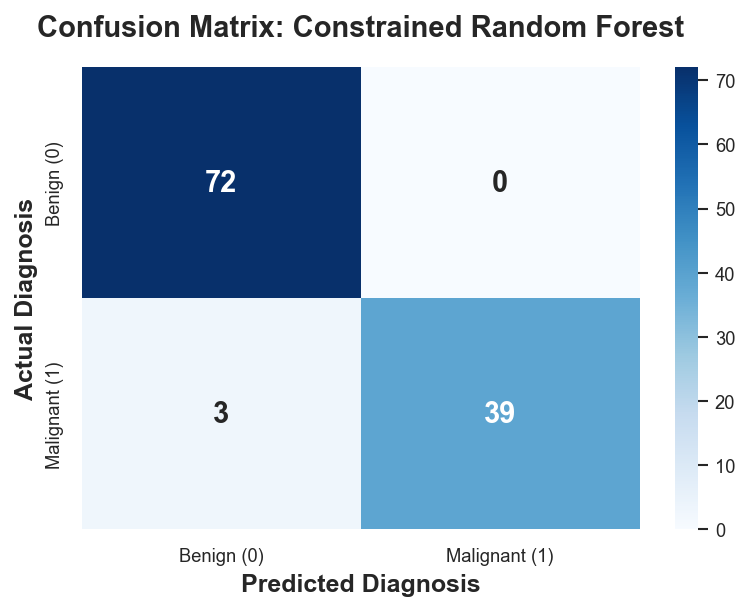


 Confusion Matrix Breakdown:
True Negatives (Benign correctly identified): 72
False Positives (Benign MISCLASSIFIED as Malignant): 0  <- WOW, check this out!
False Negatives (Malignant MISSED): 3
True Positives (Malignant correctly identified): 39

 Calculating SHAP values (this may take a few seconds)...


In [ ]:
# ==============================================================================
# Cell 4: Visual Evidences (Confusion Matrix & SHAP Explainability)
# Objective: Generate publication-quality plots for the final report
# ==============================================================================

import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import shap

print(" Generating Visualizations...")

# Output directory for figures (relative path)
FIG_DIR = '../Figures&Tables'
os.makedirs(FIG_DIR, exist_ok=True)

# ---------------------------------------------------------
# Part 1: Confusion Matrix
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'],
            annot_kws={"size": 14, "weight": "bold"})
plt.title('Confusion Matrix: Constrained Random Forest', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual Diagnosis', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Diagnosis', fontsize=12, fontweight='bold')
plt.savefig(os.path.join(FIG_DIR, 'wdbc_rf_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print CM details
tn, fp, fn, tp = cm.ravel()
print("\n Confusion Matrix Breakdown:")
print(f"True Negatives (Benign correctly identified): {tn}")
print(f"False Positives (Benign MISCLASSIFIED as Malignant): {fp}  <- WOW, check this out!")
print(f"False Negatives (Malignant MISSED): {fn}")
print(f"True Positives (Malignant correctly identified): {tp}")

# ---------------------------------------------------------
# Part 2: SHAP Beeswarm Plot
# ---------------------------------------------------------
print("\n Calculating SHAP values (this may take a few seconds)...")
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# Random Forest in SHAP returns a list [Benign values, Malignant values]
# We want to explain Malignant (Class 1)
shap_values_malignant = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_malignant, X_test, show=False, cmap='coolwarm', max_display=10)
plt.title('SHAP Analysis: Top 10 Drivers of Malignant Breast Cancer', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'wdbc_shap_beeswarm.png'), dpi=300, bbox_inches='tight')
plt.show()

print(" SUCCESS: Both images saved successfully!")